# Sensitivity Comparison: Single Material (ref) vs Multi-Material Sum

Verify that splitting the same material into two separate definitions and perturbing each independently yields the same total sensitivity as perturbing a single unified material.

| Case | Description | Materials | PERT cards |
|------|-------------|-----------|------------|
| **ref** | All Fe cells use one material (m300000) | 1 | 224 |
| **sum** | Cells 3,5,7 use m400000; cell 9 uses m300000 (same composition) | 2 | 448 |

- **ZAIDs**: 26056 (Fe-56), 26054 (Fe-54)
- **Reactions**: MT=2 (elastic), MT=51 (discrete inelastic)
- **Expected**: `S_ref == S_sum_total = S_m400000 + S_m300000` (per ZAID, per reaction)

In [1]:
import kika
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# File paths
ref_input = "/share_snc/snc/JuanMonleon/PWRSphere/PERT/ref/PWRSphere_Fe56.i"
ref_mctal = "/share_snc/snc/JuanMonleon/PWRSphere/PERT/ref/PWRSphere_Fe56.m"

sum_input = "/share_snc/snc/JuanMonleon/PWRSphere/PERT/sum/PWRSphere_Fe56.i"
sum_mctal = "/share_snc/snc/JuanMonleon/PWRSphere/PERT/sum/PWRSphere_Fe56.m"

TALLY = 4
ZAIDS = [26056, 26054]

## 1. Compute sensitivities

In [3]:
# Compute sensitivities for all ZAIDs
sens_ref = {}
sens_sum = {}

for zaid in ZAIDS:
    sens_ref[zaid] = kika.compute_sensitivity(ref_input, ref_mctal, TALLY, zaid, label=f"ref_{zaid}")
    print(f"Ref ZAID {zaid} - energies: {len(sens_ref[zaid].energies)}, reactions: {sens_ref[zaid].reactions}")

Ref ZAID 26056 - energies: 4, reactions: [2, 51]
Ref ZAID 26054 - energies: 4, reactions: [2, 51]


In [4]:
for zaid in ZAIDS:
    sens_sum[zaid] = kika.compute_total_sensitivity(sum_input, sum_mctal, TALLY, zaid, label=f"sum_{zaid}")
    print(f"Sum ZAID {zaid} - energies: {len(sens_sum[zaid].energies)}, reactions: {sens_sum[zaid].reactions}")

Sum ZAID 26056 - energies: 4, reactions: [2, 51]
Sum ZAID 26054 - energies: 4, reactions: [2, 51]


## 2. Compare sensitivity profiles

In [5]:
# Build comparison table for all ZAIDs and reactions
rows = []
for zaid in ZAIDS:
    for energy_str in sens_ref[zaid].energies:
        for rxn in sens_ref[zaid].reactions:
            ref_coef = sens_ref[zaid].data[energy_str][rxn]
            sum_coef = sens_sum[zaid].data[energy_str][rxn]
            
            ref_vals = np.array(ref_coef.values)
            sum_vals = np.array(sum_coef.values)
            ref_errs = np.array(ref_coef.errors)
            sum_errs = np.array(sum_coef.errors)
            
            for k in range(len(ref_vals)):
                e_lo = ref_coef.pert_energies[k]
                e_hi = ref_coef.pert_energies[k + 1]
                diff = sum_vals[k] - ref_vals[k]
                rel_diff = diff / ref_vals[k] if ref_vals[k] != 0 else np.nan
                rows.append({
                    "zaid": zaid,
                    "det_energy": energy_str,
                    "MT": rxn,
                    "E_lo": e_lo,
                    "E_hi": e_hi,
                    "S_ref": ref_vals[k],
                    "S_sum": sum_vals[k],
                    "err_ref": ref_errs[k],
                    "err_sum": sum_errs[k],
                    "rel_diff": rel_diff,
                })

df = pd.DataFrame(rows)
print(f"Total comparison points: {len(df)}")
print(f"ZAIDs: {df['zaid'].unique()}, Reactions: {df['MT'].unique()}")
df.head(10)

Total comparison points: 896
ZAIDs: [26056 26054], Reactions: [ 2 51]


,zaid,det_energy,MT,E_lo,E_hi,S_ref,S_sum,err_ref,err_sum,rel_diff
0,26056,0.00e+00_1.00e-01,2,1.000000e-11,4.000000e-09,-0.000016,-0.000016,1.000007,1.000007,-0.000000e+00
1,26056,0.00e+00_1.00e-01,2,4.000000e-09,1.000000e-08,0.000018,0.000018,1.000007,1.000007,0.000000e+00
2,26056,0.00e+00_1.00e-01,2,1.000000e-08,2.530000e-08,0.000024,0.000024,1.000007,0.982767,-1.401288e-16
3,26056,0.00e+00_1.00e-01,2,2.530000e-08,4.000000e-08,-0.000034,-0.000034,1.000007,1.000007,-0.000000e+00
4,26056,0.00e+00_1.00e-01,2,4.000000e-08,5.000000e-08,-0.000049,-0.000049,0.903608,0.903581,8.124017e-07
5,26056,0.00e+00_1.00e-01,2,5.000000e-08,6.000000e-08,-0.000040,-0.000040,1.000007,1.171429,7.188685e-06
6,26056,0.00e+00_1.00e-01,2,6.000000e-08,8.000000e-08,-0.000195,-0.000195,0.459315,0.459754,9.305442e-08
7,26056,0.00e+00_1.00e-01,2,8.000000e-08,1.000000e-07,-0.000238,-0.000238,0.389018,0.389342,-2.445096e-07
8,26056,0.00e+00_1.00e-01,2,1.000000e-07,1.500000e-07,-0.000660,-0.000660,0.288724,0.290718,-1.430725e-06
9,26056,0.00e+00_1.00e-01,2,1.500000e-07,2.000000e-07,-0.000811,-0.000811,0.228030,0.228679,1.522261e-06


## 3. Plot sensitivity profiles (per lethargy)

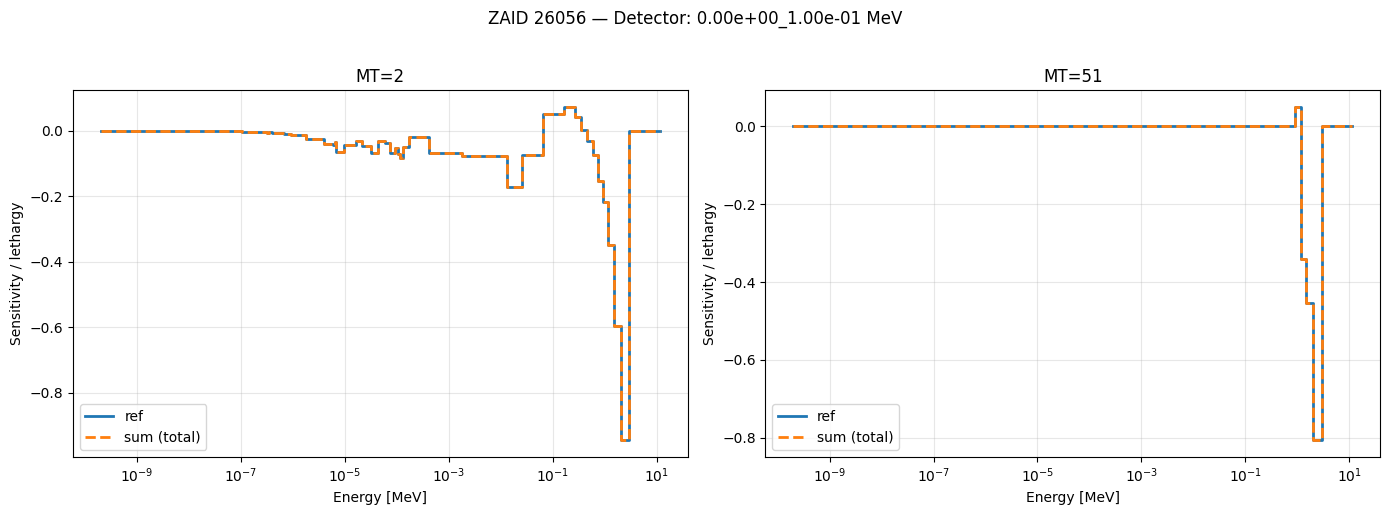

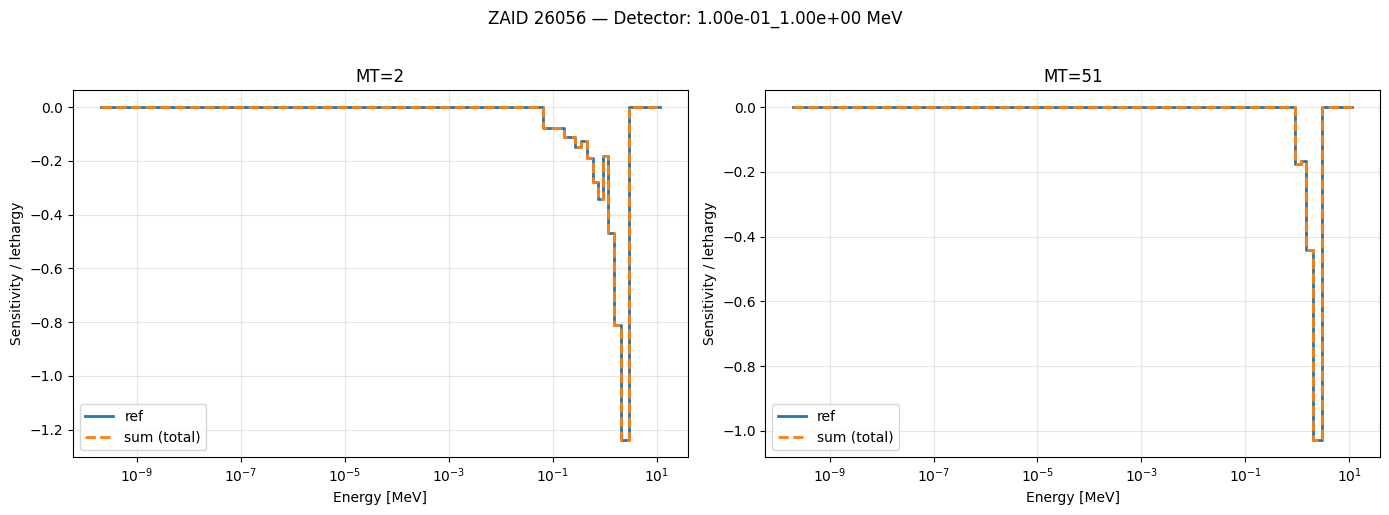

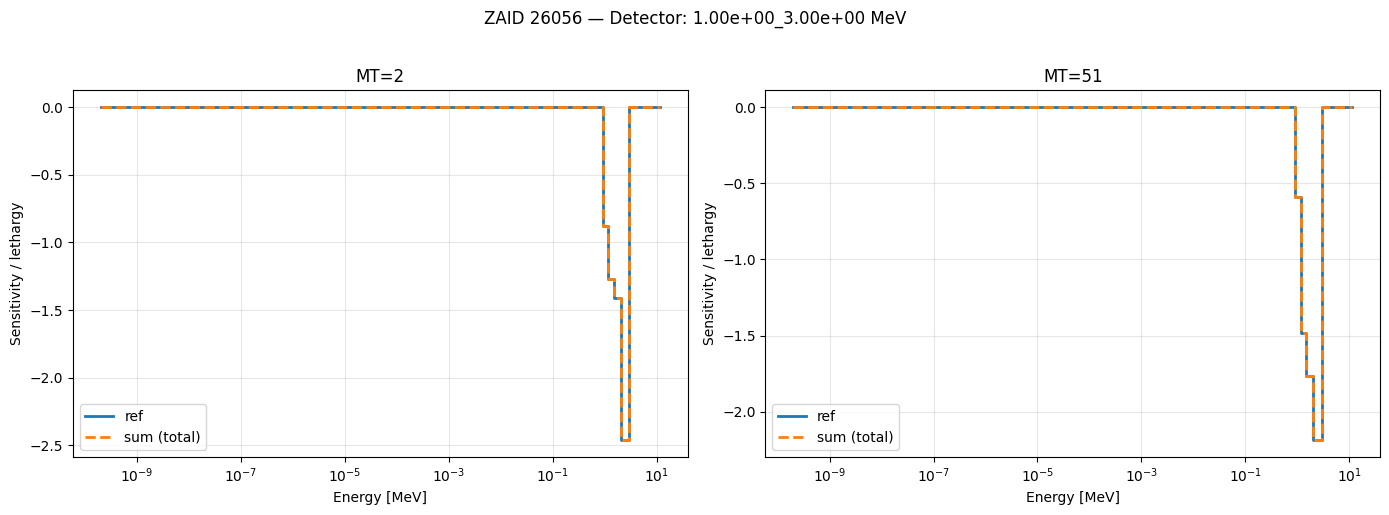

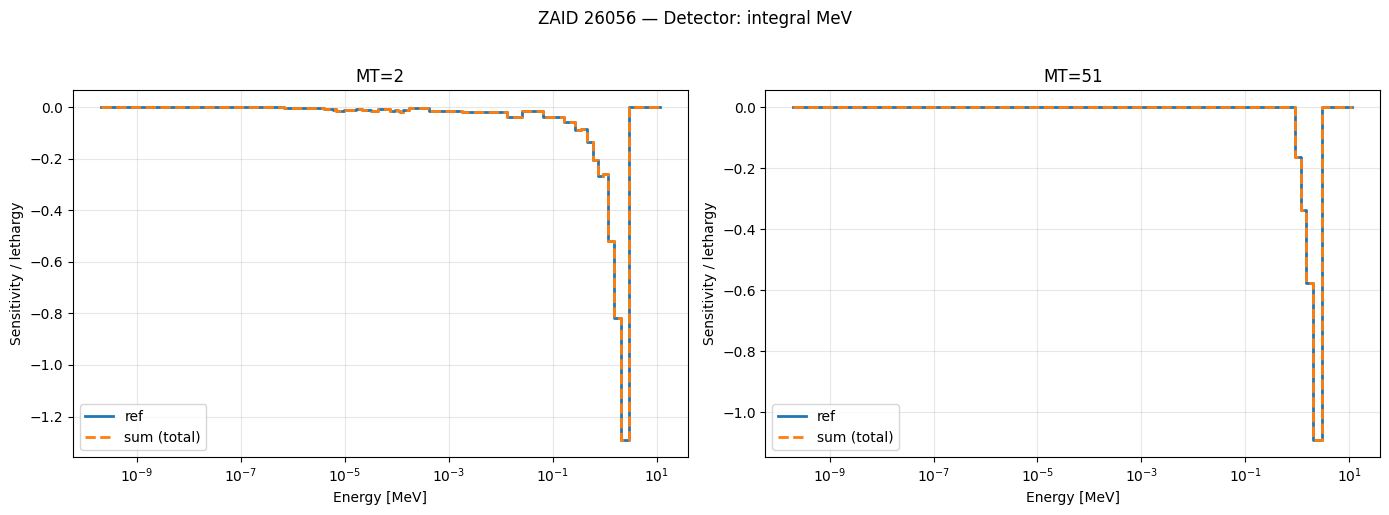

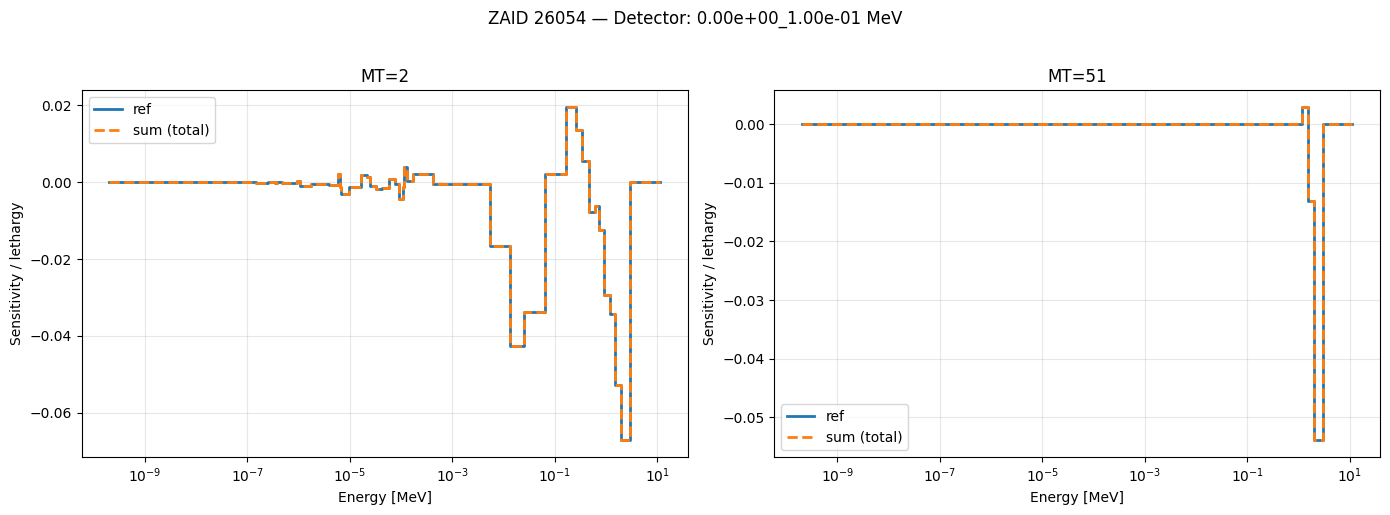

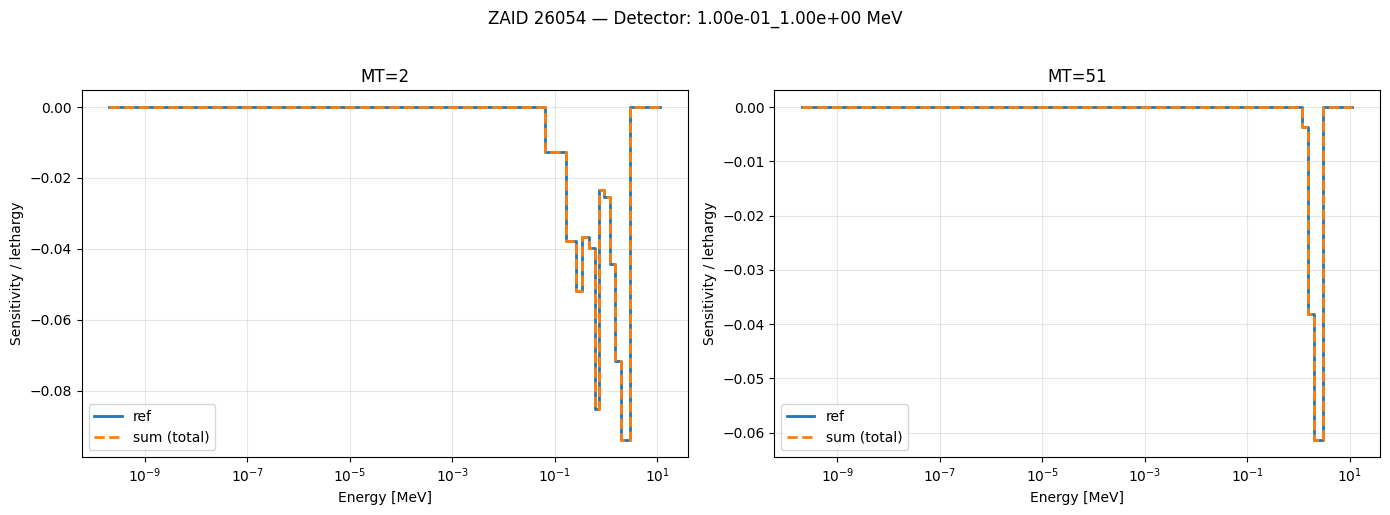

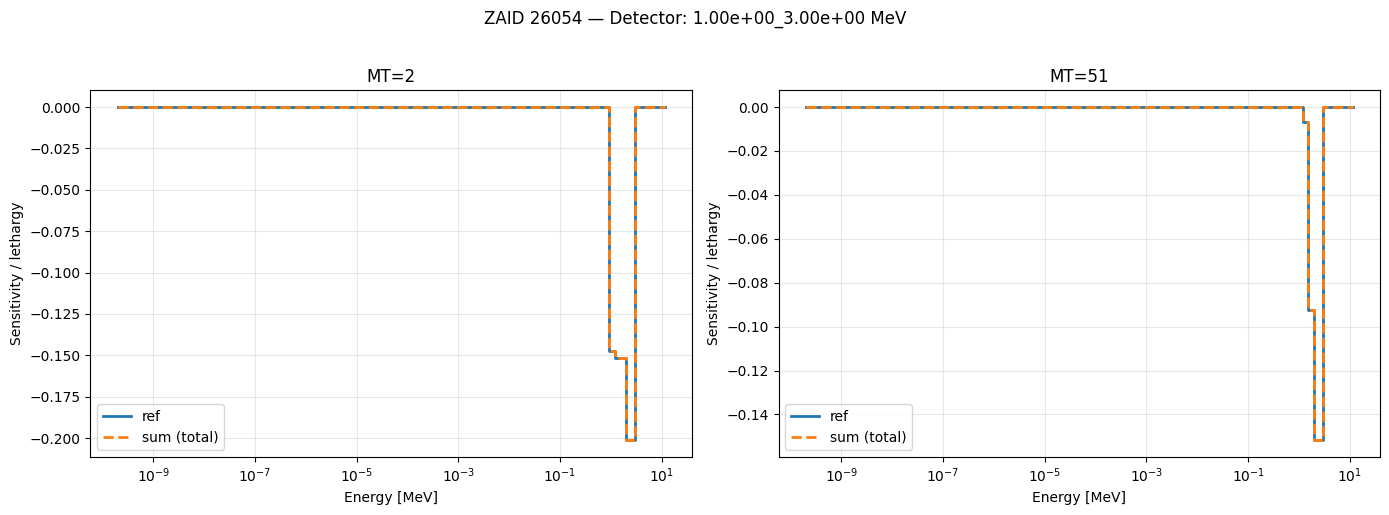

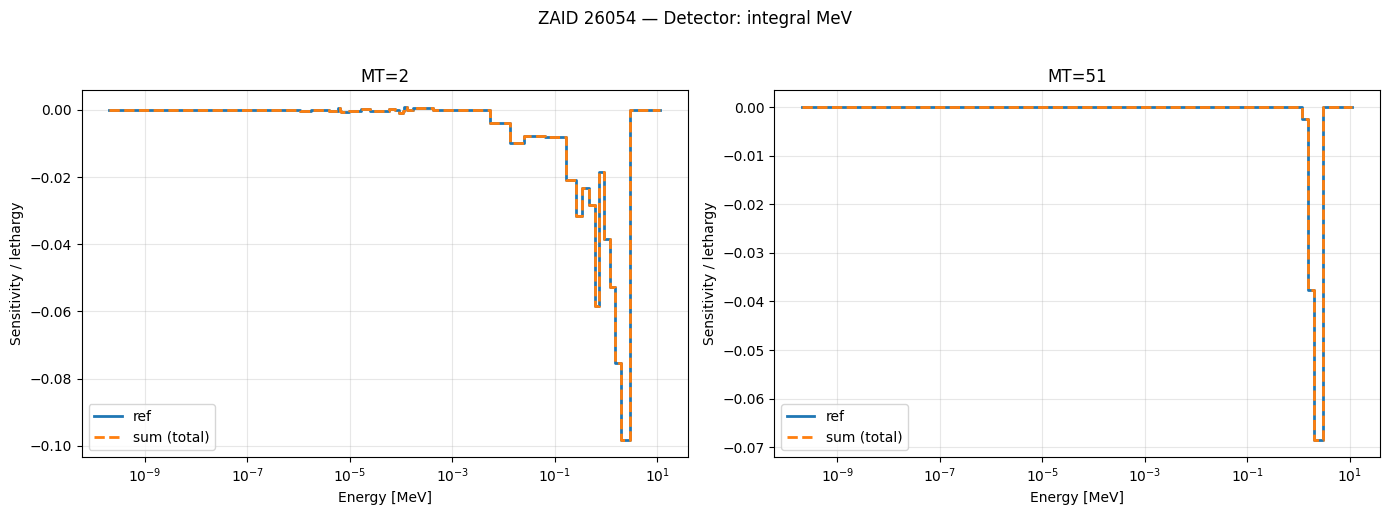

In [6]:
# Plot sensitivity profiles per ZAID, per detector energy
for zaid in ZAIDS:
    for energy_str in sens_ref[zaid].energies:
        rxns = sens_ref[zaid].reactions
        fig, axes = plt.subplots(1, len(rxns), figsize=(7 * len(rxns), 5), squeeze=False)
        
        for i, rxn in enumerate(rxns):
            ax = axes[0, i]
            ref_coef = sens_ref[zaid].data[energy_str][rxn]
            sum_coef = sens_sum[zaid].data[energy_str][rxn]
            
            emid = np.sqrt(np.array(ref_coef.pert_energies[:-1]) * np.array(ref_coef.pert_energies[1:]))
            
            ax.step(emid, ref_coef.values_per_lethargy, where="mid", label="ref", linewidth=2)
            ax.step(emid, sum_coef.values_per_lethargy, where="mid", label="sum (total)", 
                    linewidth=2, linestyle="--")
            
            ax.set_xscale("log")
            ax.set_xlabel("Energy [MeV]")
            ax.set_ylabel("Sensitivity / lethargy")
            ax.set_title(f"MT={rxn}")
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        fig.suptitle(f"ZAID {zaid} — Detector: {energy_str} MeV", y=1.02)
        plt.tight_layout()
        plt.show()

## 4. Relative differences and statistical check

Bins with good statistics: 191 / 896

ZAID 26056, MT=2: 98 bins
  Mean rel_diff:  -8.6901e-08
  Std rel_diff:   1.4680e-06
  Max |rel_diff|: 4.4806e-06

ZAID 26056, MT=51: 16 bins
  Mean rel_diff:  -4.5256e-08
  Std rel_diff:   1.8908e-06
  Max |rel_diff|: 4.3696e-06

ZAID 26054, MT=2: 65 bins
  Mean rel_diff:  -3.0679e-08
  Std rel_diff:   1.8256e-06
  Max |rel_diff|: 5.9702e-06

ZAID 26054, MT=51: 12 bins
  Mean rel_diff:  -9.6544e-09
  Std rel_diff:   2.6927e-06
  Max |rel_diff|: 6.5966e-06


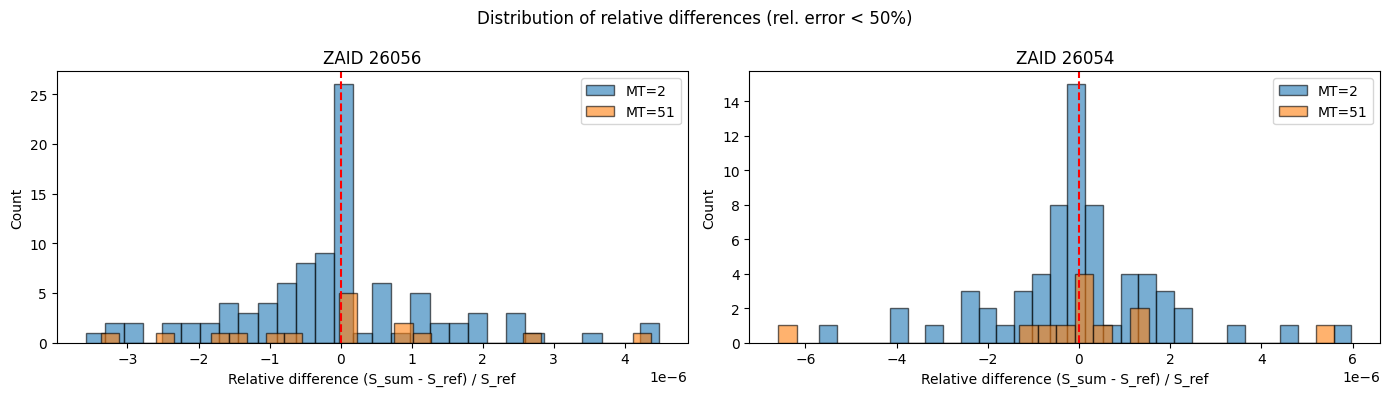

In [7]:
# Statistics per ZAID per reaction
mask = (df["err_ref"] < 0.5) & (df["err_sum"] < 0.5) & (df["S_ref"] != 0)
df_good = df[mask].copy()

print(f"Bins with good statistics: {len(df_good)} / {len(df)}")

for zaid in ZAIDS:
    for rxn in sorted(df_good["MT"].unique()):
        sub = df_good[(df_good["zaid"] == zaid) & (df_good["MT"] == rxn)]
        if len(sub) > 0:
            print(f"\nZAID {zaid}, MT={rxn}: {len(sub)} bins")
            print(f"  Mean rel_diff:  {sub['rel_diff'].mean():.4e}")
            print(f"  Std rel_diff:   {sub['rel_diff'].std():.4e}")
            print(f"  Max |rel_diff|: {sub['rel_diff'].abs().max():.4e}")

# Histogram faceted by ZAID
fig, axes = plt.subplots(1, len(ZAIDS), figsize=(7 * len(ZAIDS), 4), squeeze=False)
for i, zaid in enumerate(ZAIDS):
    ax = axes[0, i]
    sub = df_good[df_good["zaid"] == zaid]
    if len(sub) > 0:
        for rxn in sorted(sub["MT"].unique()):
            sub_rxn = sub[sub["MT"] == rxn]
            ax.hist(sub_rxn["rel_diff"].dropna(), bins=30, alpha=0.6, label=f"MT={rxn}", edgecolor="k")
        ax.axvline(0, color="r", linestyle="--")
        ax.legend()
    ax.set_xlabel("Relative difference (S_sum - S_ref) / S_ref")
    ax.set_ylabel("Count")
    ax.set_title(f"ZAID {zaid}")
plt.suptitle("Distribution of relative differences (rel. error < 50%)")
plt.tight_layout()
plt.show()

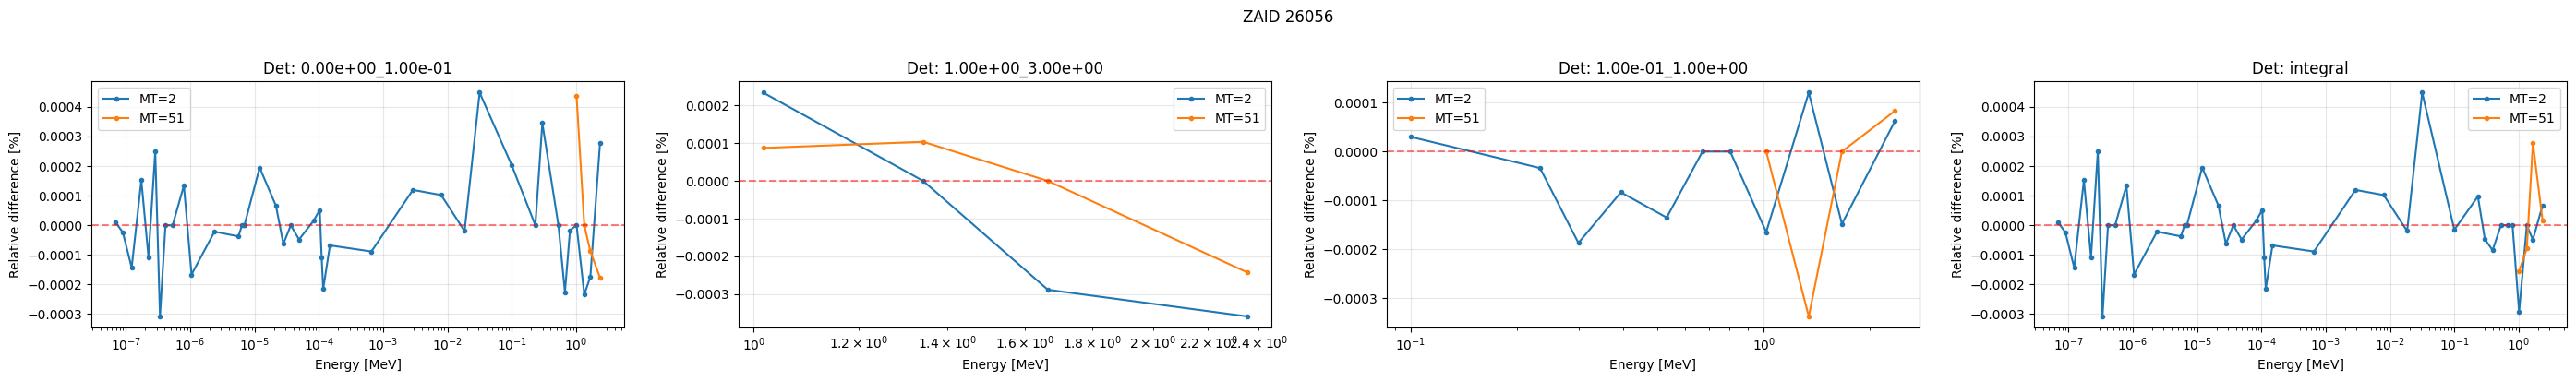

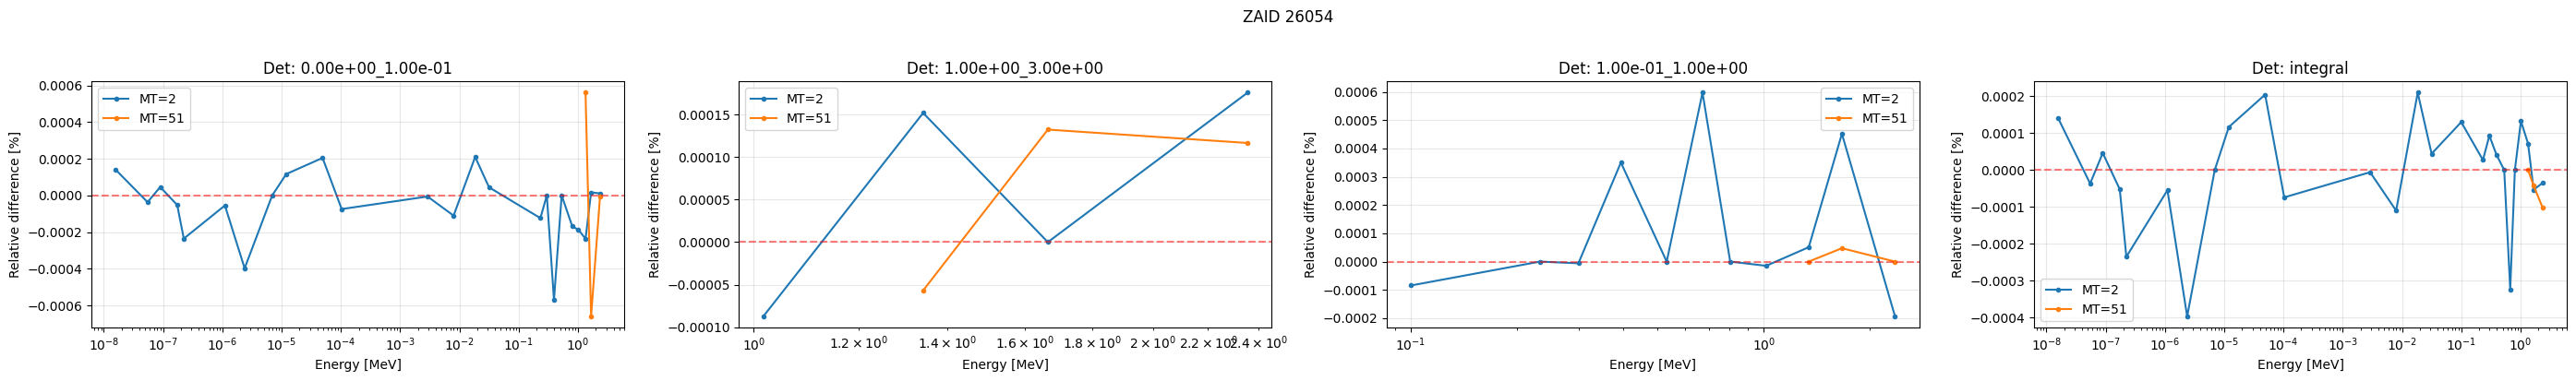

In [8]:
# Relative difference vs energy, per ZAID, colored by reaction
for zaid in ZAIDS:
    sub_zaid = df_good[df_good["zaid"] == zaid]
    energies = sorted(sub_zaid["det_energy"].unique())
    if not len(energies):
        continue
    fig, axes = plt.subplots(1, len(energies), figsize=(7 * len(energies), 4), squeeze=False)
    for i, energy_str in enumerate(energies):
        ax = axes[0, i]
        sub = sub_zaid[sub_zaid["det_energy"] == energy_str]
        for rxn in sorted(sub["MT"].unique()):
            sub_rxn = sub[sub["MT"] == rxn]
            emid = np.sqrt(sub_rxn["E_lo"].values * sub_rxn["E_hi"].values)
            ax.plot(emid, sub_rxn["rel_diff"].values * 100, "o-", markersize=3, label=f"MT={rxn}")
        ax.axhline(0, color="r", linestyle="--", alpha=0.5)
        ax.set_xscale("log")
        ax.set_xlabel("Energy [MeV]")
        ax.set_ylabel("Relative difference [%]")
        ax.set_title(f"Det: {energy_str}")
        ax.legend()
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"ZAID {zaid}", y=1.02)
    plt.tight_layout()
    plt.show()